In [107]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [108]:
df = pd.read_csv('glass.csv')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [109]:
df.shape

(214, 10)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


### EDA

In [111]:
### Handle missing value

In [112]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [113]:
df.duplicated().sum()

np.int64(1)

In [114]:
df.drop_duplicates(inplace = True)

In [115]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


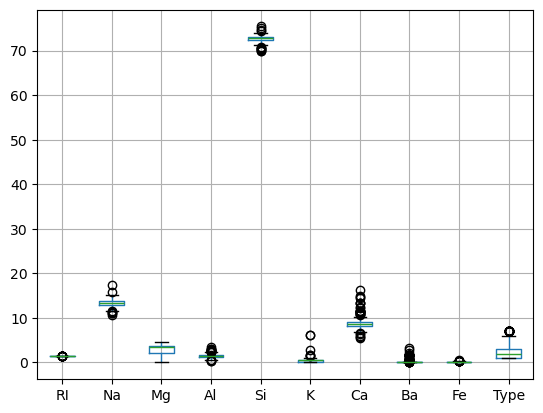

In [116]:
### outliers 

df.boxplot()
plt.show()

In [117]:
#### outlier capping
def outiler_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR=Q3-Q1
    Lower_Extreme= Q1-1.5*IQR
    Upper_Extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x:Lower_Extreme if x<Lower_Extreme else Upper_Extreme if x>Upper_Extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outiler_capping(df,col)

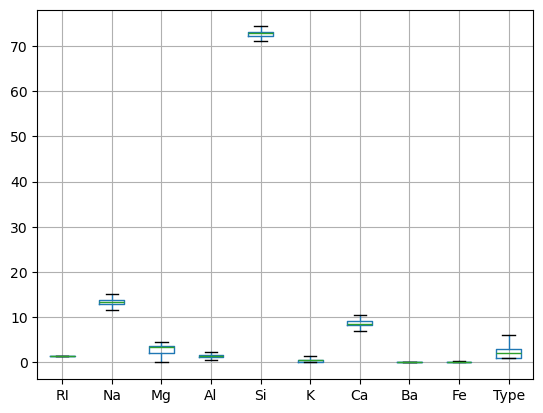

In [118]:
df.boxplot()
plt.show()

In [119]:
num_col = df.select_dtypes(include=['int','float']).columns.tolist()
num_col

['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']

### Data Visualization 

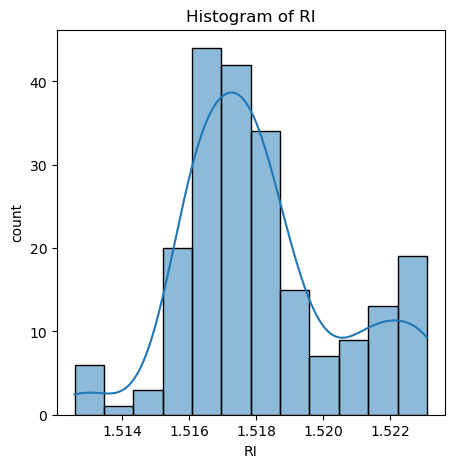

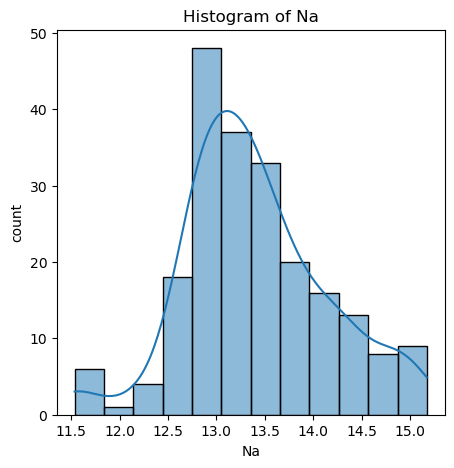

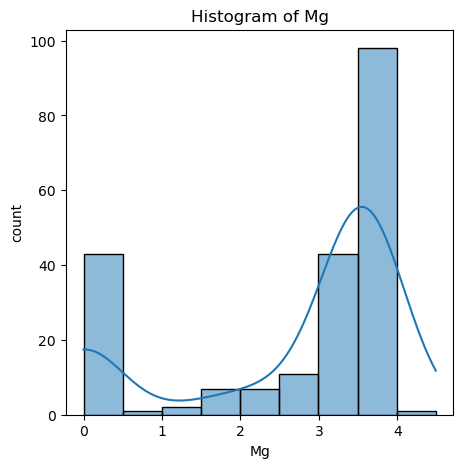

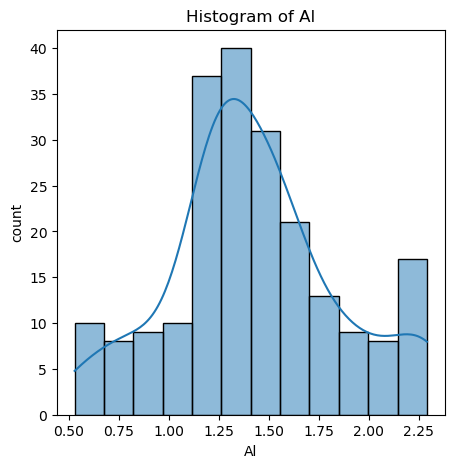

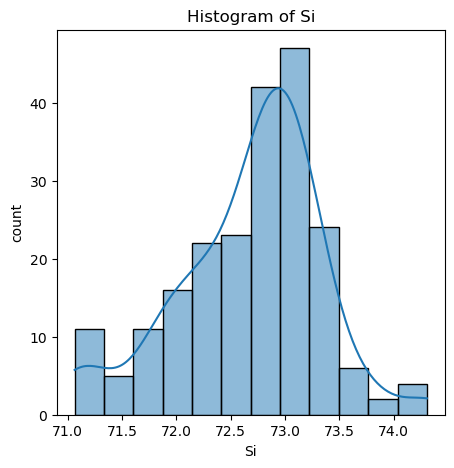

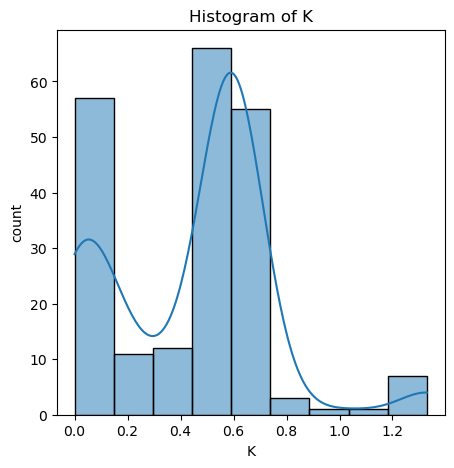

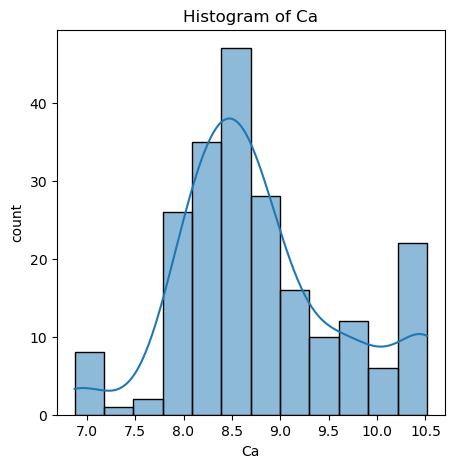

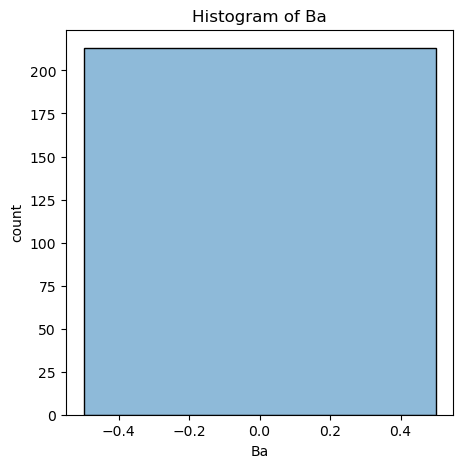

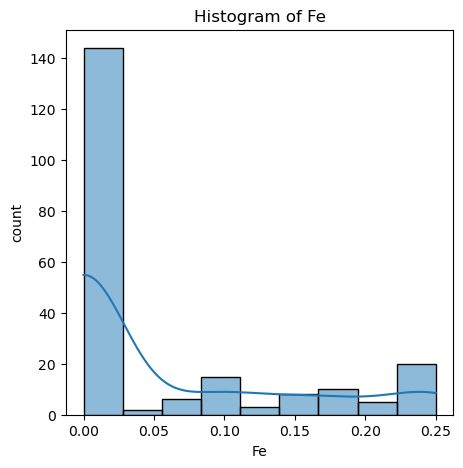

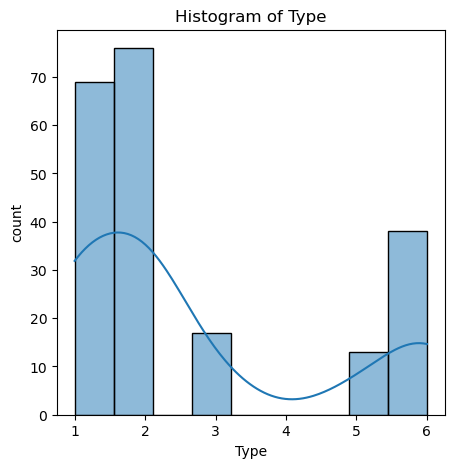

In [120]:
### Data Visualization 

for i in ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']:
    plt.figure(figsize = (5,5))
    sns.histplot(x = df[i],kde = True)
    plt.xlabel(i)
    plt.ylabel('count')
    plt.title(f'Histogram of {i}')
    plt.show()

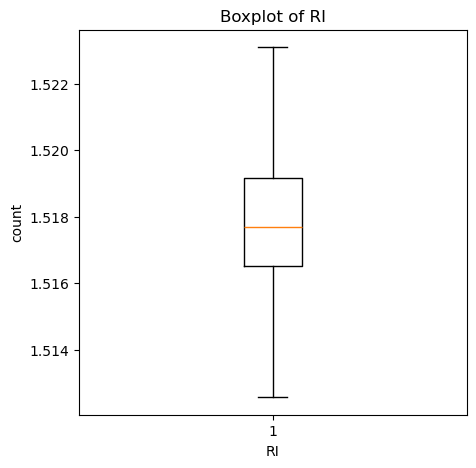

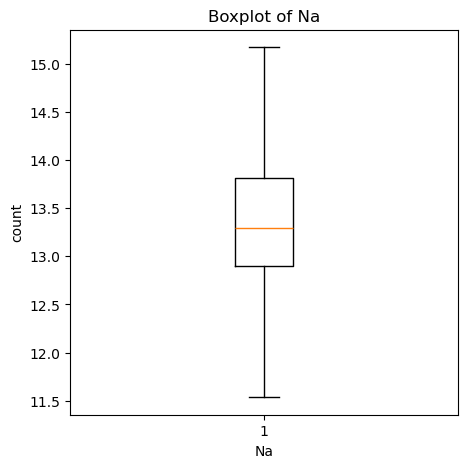

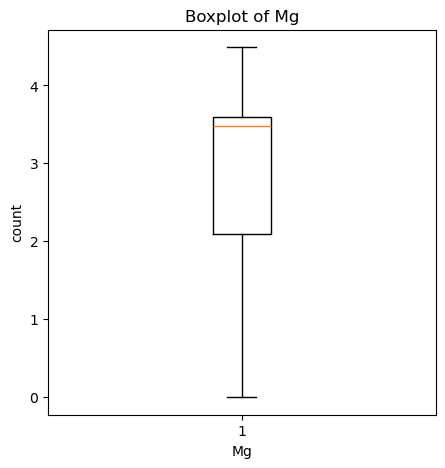

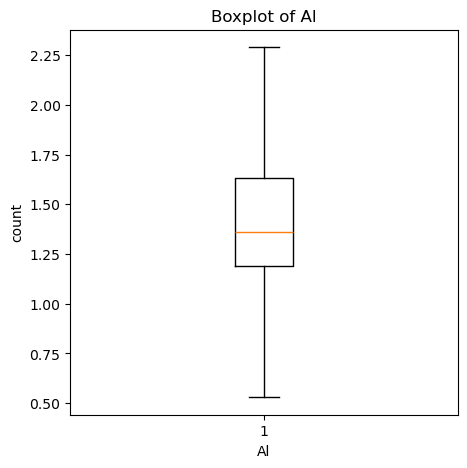

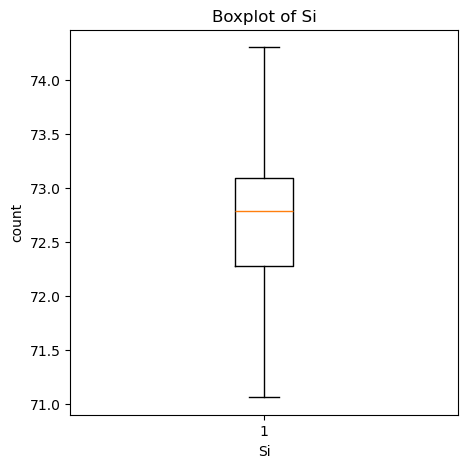

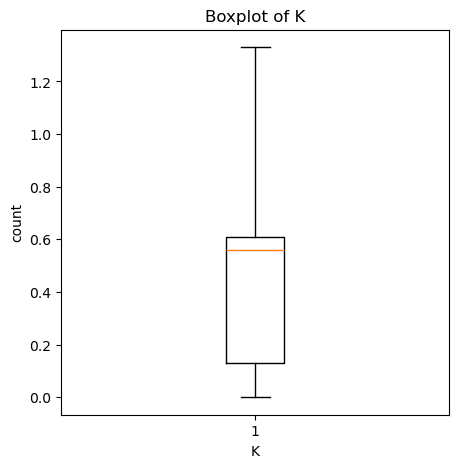

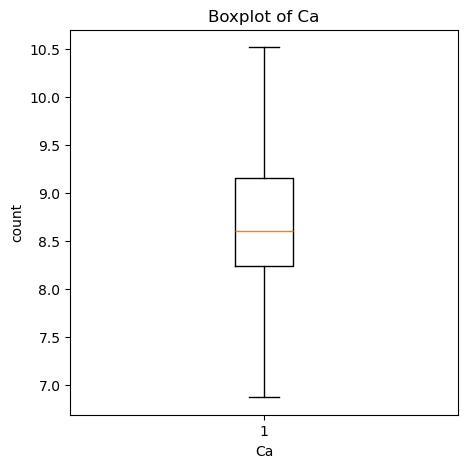

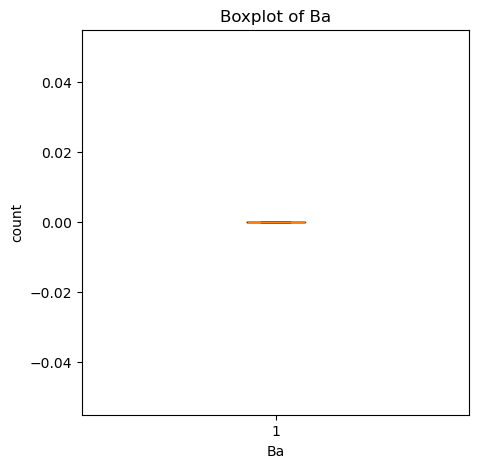

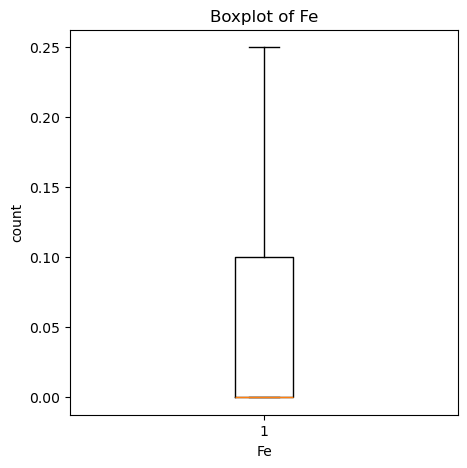

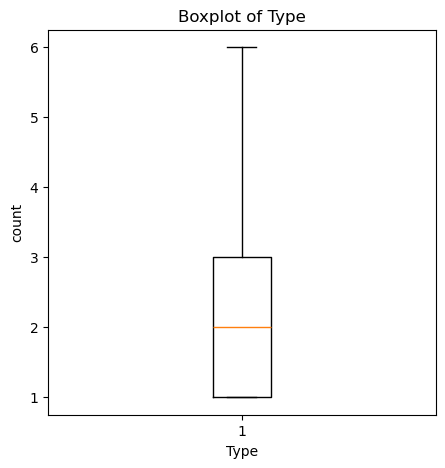

In [124]:
for i in ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']:
    plt.figure(figsize=(5,5))
    plt.boxplot(x=df[i])
    plt.xlabel(i)
    plt.ylabel('count')
    plt.title(f'Boxplot of {i}')
    plt.show()

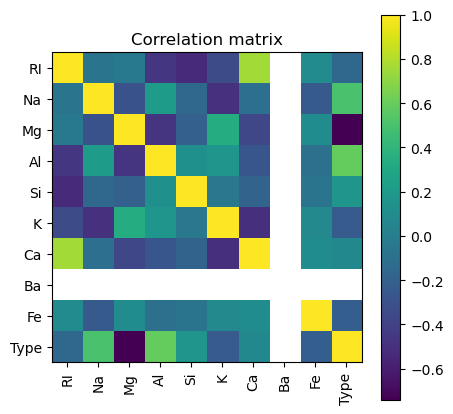

In [125]:
corr = df.corr()
plt.figure(figsize=(5,5))
plt.imshow(corr,interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)),corr.columns,rotation = 90)
plt.yticks(range(len(corr.index)),corr.index)
plt.title('Correlation matrix')
plt.show()

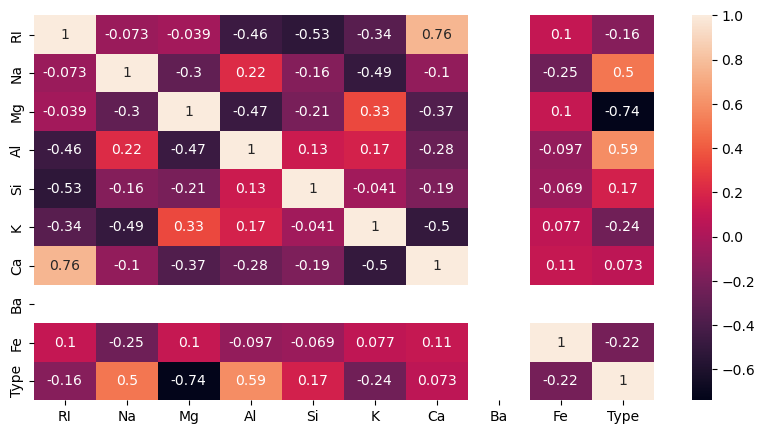

In [126]:
plt.figure(figsize = (10,5))
sns.heatmap(corr,annot=True)
plt.show()

In [138]:
cat_col = df.select_dtypes(include=['object']).columns.tolist()
cat_col

[]

### Data Preprocessing

In [139]:
from sklearn.preprocessing import Normalizer,StandardScaler

In [142]:
std_sca = StandardScaler()
df1 = pd.DataFrame(std_sca.fit_transform(df),columns=df.columns)
df1.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.216093,0.322680,1.257238,-0.773927,-1.361078,-1.253536,-0.044419,0.0,-0.621102,-0.898667
1,-0.227207,0.660556,0.639311,-0.154741,0.086641,0.124799,-1.115733,0.0,-0.621102,-0.898667
2,-0.834242,0.174014,0.604596,0.273927,0.482859,-0.170559,-1.173956,0.0,-0.621102,-0.898667
3,-0.205982,-0.258467,0.701798,-0.321445,-0.096228,0.420156,-0.661589,0.0,-0.621102,-0.898667
4,-0.307862,-0.177377,0.653197,-0.440519,0.620012,0.354521,-0.836260,0.0,-0.621102,-0.898667


In [146]:
feature = df.drop(columns=['Type'])
target = df['Type']

### Random Forest Model Implementation 

In [158]:
### train_test_split 

from sklearn.model_selection import train_test_split,GridSearchCV

In [159]:
x_train,x_test,y_train,y_test = train_test_split(feature,target,train_size=0.75,random_state=50)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(159, 9)
(54, 9)
(159,)
(54,)


In [205]:
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,BaggingClassifier,AdaBoostClassifier

In [206]:
ran_for = RandomForestClassifier()
ran_for.fit(x_train,y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [207]:
### accuracy_score,precision_score,recall_score,f1_score

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [208]:
ran_for = RandomForestClassifier(n_estimators=100,criterion = 'gini',max_depth=5,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
accuracy_score(y_test,y_pred)

0.7037037037037037

In [209]:
ran_for = RandomForestClassifier(criterion = 'gini',max_depth=5,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
precision_score(y_test,y_pred,average='micro')

0.7037037037037037

In [210]:
### Gird Search 

params = {'criterion':['gini'],'max_depth':range(1,5)}
grid_search = GridSearchCV(ran_for,params)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'criterion': 'gini', 'max_depth': 4}

In [211]:
ran_for = RandomForestClassifier(n_estimators=100,criterion = 'gini',max_depth=4,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
accuracy_score(y_test,y_pred)

0.7037037037037037

In [212]:
ran_for = RandomForestClassifier(criterion = 'gini',max_depth=5,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
precision_score(y_test,y_pred,average='micro')

0.7037037037037037

In [213]:
ran_for = RandomForestClassifier(criterion = 'gini',max_depth=5,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
f1_score(y_test,y_pred,average='micro')

0.7037037037037037

In [214]:
ran_for = RandomForestClassifier(criterion = 'gini',max_depth=5,random_state=100)
ran_for.fit(x_train,y_train)
y_pred = ran_for.predict(x_test)
recall_score(y_test,y_pred,average='micro')

0.7037037037037037

### Randoem Forest Visualization

In [246]:
estimator = ran_for.estimators_[0]

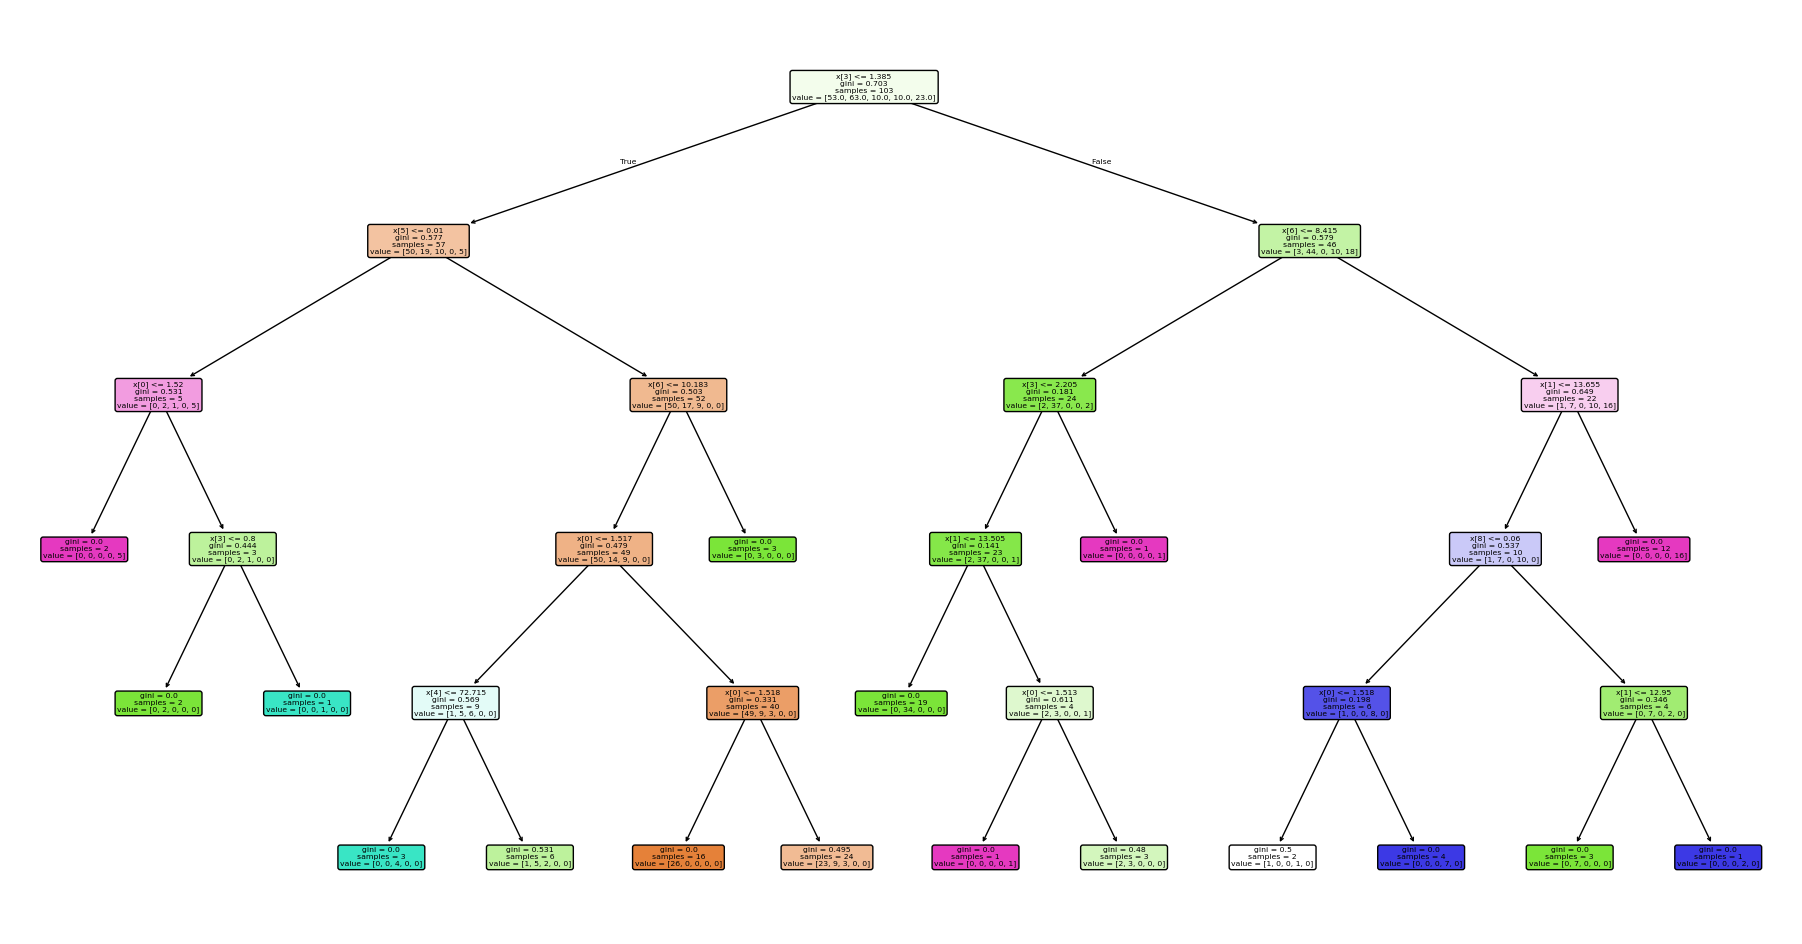

In [249]:
plt.figure(figsize=(23,12))
plot_tree(estimator, filled=True, rounded=True)
plt.show()

### Bagging and Boosting 

In [251]:
bag_model = BaggingClassifier(estimator=RandomForestClassifier(),n_estimators=50,random_state=50)
bag_model.fit(x_train,y_train)
bag_pred = bag.predict(x_test)
accuracy_score(y_test,y_pred)

0.7037037037037037

In [252]:
gb_model = GradientBoostingClassifier(n_estimators=100,learning_rate=0.1,max_depth=3,random_state=50)
gb_model.fit(x_train, y_train)
gb_pred = gb_model.predict(x_test)
accuracy_score(y_test,y_pred)

0.7037037037037037

In [253]:
ada_model = AdaBoostClassifier(n_estimators=100,learning_rate=1,random_state=50)
ada_model.fit(x_train, y_train)
ada_pred = ada_model.predict(x_test)
accuracy_score(y_test,ada_pred)

0.6296296296296297

In [254]:
models = ['Random Forest','Bagging','Gradient Boosting','AdaBoost']
acc = [accuracy_score(y_test,y_pred),accuracy_score(y_test,bag_pred),accuracy_score(y_test,gb_pred),accuracy_score(y_test,ada_pred)]

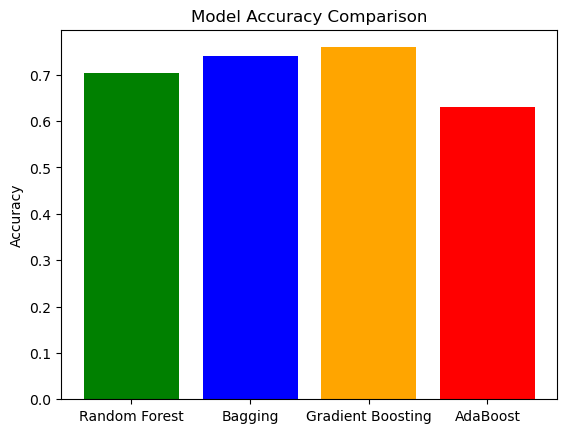

In [255]:
plt.bar(models, acc, color=['green','blue','orange','red'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

### Additional notes

##### Bagging

In [ ]:
### It is reduce varience and prevent overfitting 

Creates multiple subsets of the training data by sampling with replacement (bootstrap samples).
Trains a separate model (usually Decision Trees) on each subset.
Final prediction = majority vote (classification) or average (regression).

##### Boosting

In [ ]:
### It is reduce bias and improve accuracy but can risk overfitting is not controlled

Models are built sequentially, not independently.
Each new model tries to correct the errors of the previous one by giving more weight to misclassified samples.
Final prediction = weighted vote of all weak learners.

##### How to handle imbalance data

In [ ]:
Resampling Techniques
Class Weights


Imbalance handling = use SMOTE, class weights, or resampling + evaluate with F1, ROC-AUC instead of accuracy.